# TextGraphicalizer: Aesop fables

Run the Laya-backed `TextGraphicalizer` on stories loaded from the cached
Project Gutenberg Aesop corpus using the checked-in high-level WordNet
ontology. The estimator owns the parameterized graph display function, so
rendering can be reused outside this notebook.

> The first model load downloads the pinned Laya checkpoint into the Hugging Face cache.
> The first corpus load downloads and caches the cleaned Aesop stories.


## One-time setup

Use the Python environment selected for this project. From the repository root, run these commands once in a terminal:

```bash
python -m pip install -e ".[notebook]"
python -m ipykernel install --user --name textgraphicalizer --display-name "TextGraphicalizer"
```

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import textwrap

assert (3, 10) <= sys.version_info[:2] <= (3, 12), (
    f"Use a Python 3.10–3.12 kernel; current interpreter is {sys.version}"
)
print(f"Using Python: {sys.executable}")

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "ontology.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from textgraphicalizer import TextGraphicalizer, load_aesop_fables

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 15, "font.size": 10})
ontology_path = ROOT / "ontology.yaml"
stopwords_path = ROOT / "stopwords.yaml"
ontology_path

Using Python: /Users/f.costa/.venvs/py312/bin/python


PosixPath('/Users/f.costa/Code/TextGraphicalizer/ontology.yaml')

In [2]:
extractor = TextGraphicalizer()

## Aesop stories

In [3]:
stories = load_aesop_fables()
selected_stories = stories[1:2]
documents = [
    (story.split("\n\n", 1)[0], story)
    for story in selected_stories
]
print(f"Loaded {len(stories)} stories; graphicalizing {len(documents)}.")
for index, (title, document) in enumerate(documents, 1):
    print(f"\n--- Story {index}: {title} ---")
    print(document)

Loaded 284 stories; graphicalizing 1.

--- Story 1: THE GOOSE THAT LAID THE GOLDEN EGGS ---
THE GOOSE THAT LAID THE GOLDEN EGGS

A Man and his Wife had the good fortune to possess a Goose which laid a Golden Egg every day. Lucky though they were, they soon began to think they were not getting rich fast enough, and, imagining the bird must be made of gold inside, they decided to kill it in order to secure the whole store of precious metal at once. But when they cut it open they found it was just like any other goose. Thus, they neither got rich all at once, as they had hoped, nor enjoyed any longer the daily addition to their wealth.

Much wants more and loses all.


In [4]:
extractor.ontology = ontology_path
extractor.stopwords_path = stopwords_path

In [5]:
extractor.node_threshold = 0.25
extractor.edge_threshold = 0.3
extractor.connected = True
extractor.max_node_degree = 3
extractor.use_milp = True
extractor.use_llm = True

In [6]:
graphs = []
for title, document in documents:
    wrapped_document = "\n".join(
        textwrap.fill(
            line,
            width=150,
            break_long_words=False,
            break_on_hyphens=False,
        )
        for line in document.splitlines()
    )
    print(f"Document:\n{wrapped_document}")

    graph = extractor.transform(document)
    graphs.append((title, document, graph))
    
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Document:
THE GOOSE THAT LAID THE GOLDEN EGGS

A Man and his Wife had the good fortune to possess a Goose which laid a Golden Egg every day. Lucky though they were, they soon began to think they
were not getting rich fast enough, and, imagining the bird must be made of gold inside, they decided to kill it in order to secure the whole store of
precious metal at once. But when they cut it open they found it was just like any other goose. Thus, they neither got rich all at once, as they had
hoped, nor enjoyed any longer the daily addition to their wealth.

Much wants more and loses all.
THE GOOSE THAT LAID THE GOLDEN EGGS: 10 nodes, 14 edges


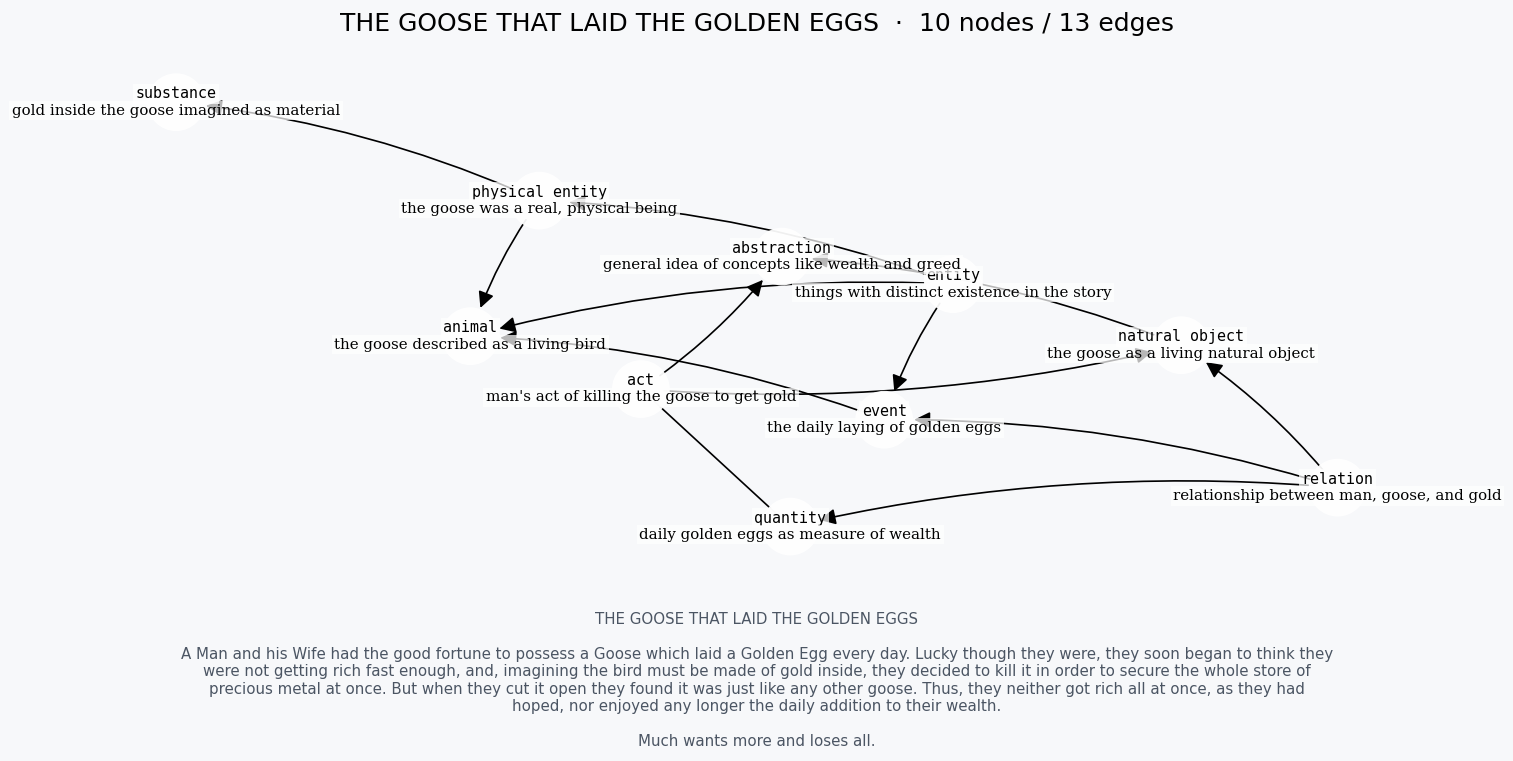

In [7]:
for title, document, graph in graphs:
    extractor.display(
        graph,
        title=title,
        document=document,
        max_char=150,
    )


In [8]:
for title, document, graph in graphs:
    display(extractor.display_d3(
        graph,
        title=title,
        document=document,
        max_char=100,
    ))


## Inspect one graph as ordinary NetworkX data

In [9]:
title, document, graph = graphs[0]
print("Story:", title)
print("Nodes:")
display(list(graph.nodes(data=True)))
print("Edges:")
display(list(graph.edges(data=True)))
print("Graph metadata:")
display(graph.graph)


Story: THE GOOSE THAT LAID THE GOLDEN EGGS
Nodes:


[('entity',
  {'label': 'Entity',
   'probability': 0.6701,
   'confidence': 0.6701,
   'paraphrase': 'things with distinct existence in the story',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('physical_entity',
  {'label': 'Physical entity',
   'probability': 0.8249,
   'confidence': 0.8249,
   'paraphrase': 'the goose was a real, physical being',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('abstraction',
  {'label': 'Abstraction',
   'probability': 0.2097,
   'confidence': 0.7903,
   'paraphrase': 'general idea of concepts like wealth and greed',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('natural_object',
  {'label': 'Natural object',
   'probability': 0.8708,
   'confidence': 0.8708,
   'paraphrase': 'the goose as a living natural object',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('animal',
  {'label': 'Animal',
   'probability': 0.762,
   '

Edges:


[('entity',
  'physical_entity',
  {'label': 'is a',
   'relation_id': 'is_a',
   'probability': 0.3017,
   'existence_probability': 0.3017,
   'relation_probability': 0.3017,
   'confidence': 0.0282,
   'paraphrase': 'the goose is described as a physical thing',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('entity',
  'animal',
  {'label': 'is a',
   'relation_id': 'is_a',
   'probability': 0.315,
   'existence_probability': 0.315,
   'relation_probability': 0.315,
   'confidence': 0.0354,
   'paraphrase': 'the goose is identified as an animal',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 ('entity',
  'event',
  {'label': 'is a',
   'relation_id': 'is_a',
   'probability': 0.3189,
   'existence_probability': 0.3189,
   'relation_probability': 0.3189,
   'confidence': 0.0466,
   'paraphrase': 'the egg-laying is an event involving the goose',
   'grounding_score': 1.0,
   'grounding_method': 'openai_llm_paraphrase'}),
 

Graph metadata:


{'ontology_version': 1,
 'model_id': 'convaiinnovations/laya',
 'model_revision': '7c76b622dfc5cac71b2dc1c29873efe2ce509a05',
 'node_threshold': 0.25,
 'edge_threshold': 0.3,
 'use_milp': True,
 'connected': True,
 'max_node_degree': 3,
 'solver': 'scipy.optimize.milp',
 'grounding_stopwords_removed': False,
 'stopwords_path': '/Users/f.costa/Code/TextGraphicalizer/stopwords.yaml',
 'stopwords_count': 174,
 'grounding_candidate_words': ['GOOSE',
  'LAID',
  'GOLDEN',
  'EGGS',
  'Man',
  'Wife',
  'good',
  'fortune',
  'possess',
  'Goose',
  'laid',
  'Golden',
  'Egg',
  'every',
  'day',
  'Lucky',
  'though',
  'soon',
  'began',
  'think',
  'getting',
  'rich',
  'fast',
  'enough',
  'imagining',
  'bird',
  'must',
  'made',
  'gold',
  'inside',
  'decided',
  'kill',
  'order',
  'secure',
  'whole',
  'store',
  'precious',
  'metal',
  'cut',
  'open',
  'found',
  'just',
  'like',
  'goose',
  'Thus',
  'neither',
  'got',
  'rich',
  'hoped',
  'enjoyed',
  'longer',
  